The leaderboard gives your agent one number. Its replays give away everything else: whether it is a script anyone can copy verbatim, which opponents already play your exact plan, where its economy trails the leader, and whether the number under your name has even settled. This notebook reads all of it, for any submission. By default it hunts down **whoever is number one right now**, resolved at run time by climbing the live ladder, and x-rays them; **fork it and put your own id in the next cell to x-ray yourself.** Scheduled daily, this page is always the reigning king's x-ray, never a stale one.

One run answers, in order:

* **How is it doing?** The win-loss-tie ledger and the margin of every episode, in play order.
* **What does it actually play?** The stripe panels: one plan or several, and where it deviates from its own mode.
* **What kind of agent is it?** Pure replay, script with repairs, shop router, or live policy, classified globally and within each world so routing is not mistaken for reactivity.
* **Who have you been playing?** The kinship spectrum: which opponents run your exact lineage, which are siblings, and whether mirrors are finding you.
* **What did your economy do?** Land timing, herd, care, endgame hygiene and money by day, each against the measured shape of the leader.
* **Can the rating be quoted yet?** Drift per episode, sign flips, and a verdict with its threshold stated.

No API token and no attached data: the episode list comes from the competition's public episode service and the replays from the public CDN (the fork needs the notebook's Internet toggle, which ships on here and which Kaggle gates behind phone verification), the same route [georgymamarin's kaggriculture-episodes dataset](https://www.kaggle.com/datasets/georgymamarin/kaggriculture-episodes) crawls nightly, credit to his scraper for the endpoint. Fetching is the slow part, about 25 MB per replay, so the default caps at 40 episodes and a run takes a few minutes.

The view behind it is the stripe texture I have used to read other people's agents for weeks ([a DNA test for agents](https://www.kaggle.com/code/destbreso/a-dna-test-for-agents), [a week-four X-ray of the top twelve](https://www.kaggle.com/code/destbreso/a-week-four-x-ray-of-the-top-twelve)): one row per real episode, one column per turn, three colors:

* **green** where the episode plays its submission's own modal action at that turn,
* **amber** where only the market channel differs,
* **navy** where the plan itself (farmer or hands) differs.

The first run against my own live agent found **four opponents running my exact lineage**, three of them action-identical on all 719 turns, an endgame stranding **sixty times less money at the bell than the leader tolerates**, and a rating still moving at 1.3 points a game, which by my own threshold is not yet a number worth quoting. One run.

## 1. The submission and its ledger

Put a submission id below, or leave "KING" to read today's number one. The listing alone already answers the first questions: how many games, the win-loss-tie ledger, and the margin of every episode in play order.

In [19]:
SUBMISSION_ID = "56171490"     # <- put YOUR submission id here; "KING" resolves today's number one
MAX_EPISODES  = 40         # newest first. NOT an arbitrary 40: measured on a
                           # 40-game sample, the dense board layers stabilise by
                           # n=16 (half-split r 0.99), but 40 games still see only
                           # ~40% of the field's distinct behaviours and ~71% of
                           # its shop pairs, by Chao/Colwell extrapolation. Raise
                           # it to ~73 to cover the worlds, ~184 for behaviours.
BASELINE_EPISODES = 12     # of the KING, for the comparison band. Costs one
                           # replay download each, so it is deliberately small

import json, collections
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

LIST_URL   = "https://www.kaggle.com/api/i/competitions.EpisodeService/ListEpisodes"
REPLAY_URL = "https://www.kaggleusercontent.com/episodes/{id}.json"
SAME, MUT, PLAN = "#DCEEE1", "#B45309", "#0F172A"

In [20]:
def _resolve_king(seed=55897276, max_hops=15):
    """Climb the live ladder: the matchmaker pairs similar ratings, so from
    any live submission, hopping to the best-rated opponent seen in its
    recent episodes converges to the top in a handful of hops. The fixed
    point, a submission whose whole recent neighbourhood rates below it, is
    the reigning number one, read from the ladder itself at run time. No
    leaderboard endpoint, no dataset, no staleness: every hop's rating comes
    stamped on a real episode."""
    cur, seen, path = seed, set(), []
    for _ in range(max_hops):
        eps = requests.post(LIST_URL, json={"submissionId": int(cur)},
                            timeout=30).json().get("episodes", [])
        eps = [e for e in eps if e.get("state") == "COMPLETED" and e.get("endTime")]
        eps.sort(key=lambda e: e["endTime"], reverse=True)
        my, nb = None, {}
        for e in eps[:30]:
            for a in e["agents"]:
                s, sc = a.get("submissionId"), a.get("updatedScore")
                if s is None or sc is None:
                    continue
                if s == cur:
                    my = my if my is not None else sc
                else:
                    nb.setdefault(s, sc)
        path.append((cur, my))
        if not nb:
            break
        best = max(nb, key=nb.get)
        if nb[best] <= (my or 0) or best in seen:
            break
        seen.add(cur)
        cur = best
    print("king resolved by climbing the live ladder: "
          + " -> ".join(f"{r:,.0f}" for _, r in path if r is not None))
    return path[-1][0]

if str(SUBMISSION_ID).upper() == "KING":
    SUBMISSION_ID = _resolve_king()
    print(f"today's number one: submission {SUBMISSION_ID}")
SUBMISSION_ID = int(SUBMISSION_ID)

In [21]:
PASSY = ("PASS", None)

def macro_indicators(steps, me):
    """The macroeconomic core of one episode, read from the replay: when land
    arrived, the herd, CARE, endgame hygiene, and money by day."""
    land_days, bought = {}, {}
    care = pass_work = shed_cap = floor_sells = 0
    for t, s in enumerate(steps):
        obs = s[me]["observation"]
        day = obs.get("day", t // 24)
        farm = obs["farms"][me]
        act = s[me]["action"] or {}
        priv = obs.get("private") or {}
        shed = priv.get("shed") or {}
        prices = obs["market"]["prices"]
        land_days.setdefault(len(farm.get("unlocked_quadrants") or []), day)
        tiles = [t2 for row in farm["tiles"] for t2 in row if isinstance(t2, dict)]
        unwatered = sum(1 for t2 in tiles if t2.get("crop") and not t2.get("watered_today"))
        ready = sum(1 for t2 in tiles if (t2.get("yield_units") or 0) > 0)
        empties = sum(1 for row in farm["tiles"] for t2 in row if t2 is None)
        seeds = sum((priv.get("seeds") or {}).values())
        work = unwatered + ready + (empties if seeds and day <= 26 else 0)
        farmer = act.get("farmer") or ["PASS"]
        hands = act.get("hands") or []
        idle = (1 if farmer[0] in PASSY else 0)             + max(0, len(farm.get("hands") or []) - len([h for h in hands if h]))
        if work > 0 and idle:
            pass_work += min(idle, work)
        if farmer[0] == "CARE":
            care += 1
        care += sum(1 for h in hands if h and h[0] == "CARE")
        if sum(v for k, v in shed.items() if k not in ("COW", "GOOSE", "SHEEP")) >= 100:
            shed_cap += 1
        for mo in (act.get("market") or []):
            if mo and mo[0] == "BUY_ANIMAL":
                bought[mo[1]] = bought.get(mo[1], 0) + 1
            if mo and mo[0] == "SELL" and prices.get(mo[1], 0) <= 2:
                floor_sells += 1
    last = steps[-1][me]["observation"]
    lp = last["market"]["prices"]
    lpriv = last.get("private") or {}
    stranded = sum(v * lp.get(k, 0) for k, v in (lpriv.get("shed") or {}).items()
                   if k not in ("COW", "GOOSE", "SHEEP"))
    for inv in (lpriv.get("inventories") or []):
        stranded += sum(v * lp.get(k, 0) for k, v in (inv or {}).items()
                        if k not in ("COW", "GOOSE", "SHEEP"))
    fallow = []
    for t in range(25 * 24, len(steps), 24):
        obs = steps[t][me]["observation"]
        if sum((obs.get("private", {}).get("seeds") or {}).values()):
            fallow.append(sum(1 for row in obs["farms"][me]["tiles"]
                              for t2 in row if t2 is None))
    money = [steps[min(d * 24, len(steps) - 1)][me]["observation"]
             ["farms"][me].get("money") or 0 for d in range(30)]
    money.append(steps[-1][me]["reward"] or 0)
    return dict(land2=land_days.get(2), land3=land_days.get(3), care=care, herd=bought,
                fallow_late=round(sum(fallow) / len(fallow), 1) if fallow else 0,
                stranded=round(stranded), pass_work=pass_work,
                shed_cap_turns=shed_cap, floor_sells=floor_sells,
                money_by_day=money)

submission 56171490: 45 episodes on the ladder, reading the newest 40
W16-L24-T0, margin median -2,695, worst -45,899, best +46,451


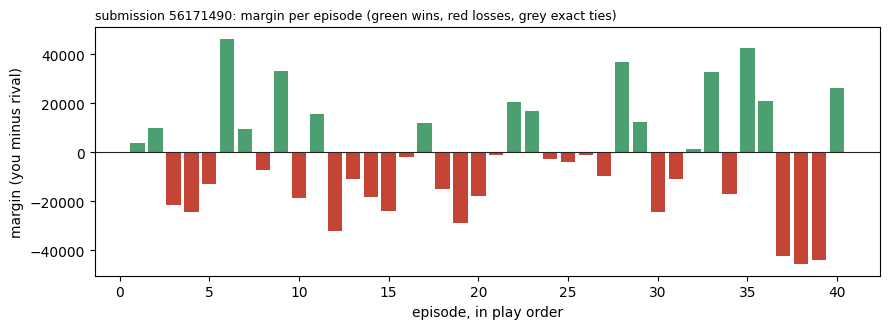

In [22]:
eps = requests.post(LIST_URL, json={"submissionId": SUBMISSION_ID},
                    timeout=30).json().get("episodes", [])
eps = [e for e in eps if e.get("state") == "COMPLETED"]
eps.sort(key=lambda e: e.get("endTime") or "", reverse=True)
mine = []
for e in eps[:MAX_EPISODES]:
    seats = {(a.get("index") or 0): a for a in e["agents"]}
    me = next(i for i, a in seats.items() if a.get("submissionId") == SUBMISSION_ID)
    mine.append(dict(episode=e["id"], seat=me,
                     opp_sub=seats[1 - me].get("submissionId"),
                     bank=seats[me].get("reward") or 0,
                     margin=(seats[me].get("reward") or 0) - (seats[1 - me].get("reward") or 0)))
if not mine:
    raise SystemExit(f"no completed episodes yet for submission {SUBMISSION_ID}; "
                     "a brand-new submission gets its first ones within hours")
traj = []
for e in sorted(eps, key=lambda e: e.get("endTime") or ""):
    seats = {(a.get("index") or 0): a for a in e["agents"]}
    me = next((i for i, a in seats.items()
               if a.get("submissionId") == SUBMISSION_ID), None)
    if me is not None and seats[me].get("updatedScore") is not None:
        traj.append(seats[me]["updatedScore"])
mg = sorted(m["margin"] for m in mine)
W = sum(1 for m in mine if m["margin"] > 0); L = sum(1 for m in mine if m["margin"] < 0)
print(f"submission {SUBMISSION_ID}: {len(eps)} episodes on the ladder, reading the newest {len(mine)}")
print(f"W{W}-L{L}-T{len(mine)-W-L}, margin median {mg[len(mg)//2]:+,.0f}, "
      f"worst {mg[0]:+,.0f}, best {mg[-1]:+,.0f}")
chron = sorted(mine, key=lambda m: m["episode"])
cols = ["#4c9f70" if m["margin"] > 0 else "#c44536" if m["margin"] < 0 else "#8a8f98"
        for m in chron]
figL, axL = plt.subplots(figsize=(9, 3.4))
axL.bar(range(1, len(chron) + 1), [m["margin"] for m in chron], color=cols, width=0.8)
axL.axhline(0, color="#222", lw=0.8)
axL.set_xlabel("episode, in play order")
axL.set_ylabel("margin (you minus rival)")
axL.set_title(f"submission {SUBMISSION_ID}: margin per episode "
              "(green wins, red losses, grey exact ties)", fontsize=9, loc="left")
plt.tight_layout(); plt.show()

In [23]:
PASS = {"farmer": ["PASS"], "hands": [], "market": []}
Z = lambda: [[0] * 10 for _ in range(10)]
OCC, PRES, UNLOCKED = Z(), Z(), Z()
OCC_DAY = {}
OCC_HALF, PRES_HALF = [Z(), Z()], [Z(), Z()]
rows = []
for k, m in enumerate(mine):
    r = requests.get(REPLAY_URL.format(id=m["episode"]), timeout=120)
    if not r.ok:
        continue
    blob = r.json()
    steps = blob.get("steps") or []
    if len(steps) < 700:
        continue
    me = m["seat"]
    # the action decided at turn t is stored at steps[t + 1]
    stream = [(steps[t + 1][me]["action"] if t + 1 < len(steps) else None) or PASS
              for t in range(719)]
    opp_stream = [(steps[t + 1][1 - me]["action"] if t + 1 < len(steps) else None) or PASS
                  for t in range(719)]
    names = blob.get("info", {}).get("TeamNames") or ["?", "?"]
    # the BOARD, accumulated while the blob is in hand rather than downloaded
    # twice. Two accumulators, alternating episodes, so the map can be checked
    # against a random half of itself instead of trusted because it looks
    # structured (every heat map does).
    half = k % 2
    for t, st in enumerate(steps):
        farms = (st[0].get("observation") or {}).get("farms") or []
        if len(farms) <= me:
            continue
        farm = farms[me]
        day = t // 24
        for yy, row in enumerate(farm.get("tiles") or []):
            for xx, cell in enumerate(row):
                if cell == "LOCKED":
                    continue
                UNLOCKED[yy][xx] += 1
                if isinstance(cell, dict):
                    OCC[yy][xx] += 1
                    OCC_DAY.setdefault(day, [[0]*10 for _ in range(10)])[yy][xx] += 1
                    OCC_HALF[half][yy][xx] += 1
        for pos in ([farm.get("farmer")] + list(farm.get("hands") or [])):
            if isinstance(pos, (list, tuple)) and len(pos) == 2:
                px, py = int(pos[0]), int(pos[1])
                if 0 <= px < 10 and 0 <= py < 10:
                    PRES[py][px] += 1
                    PRES_HALF[half][py][px] += 1
    # per-turn money for BOTH seats and the price book, for the money-flow
    # chart: kept as flat lists, ~30 KB an episode
    _sh = [(st[0].get("observation") or {}) for st in steps]
    money_me  = [((o.get("farms") or [{}, {}])[me].get("money") or 0) for o in _sh]
    money_op  = [((o.get("farms") or [{}, {}])[1 - me].get("money") or 0) for o in _sh]
    prices_t  = [((o.get("market") or {}).get("prices") or {}) for o in _sh]
    def _hands_at(seat2, d2):
        o = _sh[min(d2 * 24 + 12, len(_sh) - 1)]
        f2 = (o.get("farms") or [])
        return len(f2[seat2].get("hands") or []) if len(f2) > seat2 else 0
    hands_me  = [_hands_at(me, d2) for d2 in range(30)]
    hands_op  = [_hands_at(1 - me, d2) for d2 in range(30)]
    town = steps[150][0]["observation"].get("town") or {}
    shops = list(town.get("unlocked_shops") or [])[:2]
    rows.append(dict(episode=m["episode"], margin=m["margin"], opp_sub=m["opp_sub"],
                     pair="__".join(shops) if len(shops) == 2 else "?",
                     stream=stream, opp_stream=opp_stream, opp=names[1 - me],
                     macro=macro_indicators(steps, me),
                     money_me=money_me, money_op=money_op, prices_t=prices_t,
                     hands_me=hands_me, hands_op=hands_op))
    if (k + 1) % 10 == 0:
        print(f"  {k + 1}/{len(mine)} replays fetched")
if not rows:
    raise SystemExit("no replays could be fetched; the CDN may be briefly unavailable, rerun")
rows.sort(key=lambda r: (r["pair"], r["episode"]))
print(f"{len(rows)} replays loaded, {len({r['pair'] for r in rows})} distinct shop pairs")

  10/40 replays fetched
  20/40 replays fetched
  30/40 replays fetched
  40/40 replays fetched
40 replays loaded, 29 distinct shop pairs


## 2. The stripes

The stripe matrix compares every episode against the submission's own mode, turn by turn. Order inside the market list is meaningful in this game (orders settle index by index), so it is compared as a sequence, never sorted away.

In [24]:
def canon(a):
    if not a:
        return ("PASS", (), ())
    return (tuple(a.get("farmer") or ["PASS"]),
            tuple(tuple(h) for h in (a.get("hands") or [])),
            tuple(tuple(o) for o in (a.get("market") or [])))

n = min(len(r["stream"]) for r in rows)
modal = []
for t in range(n):
    cnt = collections.Counter(canon(r["stream"][t]) for r in rows)
    modal.append(cnt.most_common(1)[0][0])
mat = []
for r in rows:
    line = []
    for t in range(n):
        a, m = canon(r["stream"][t]), modal[t]
        line.append(2 if (a[0], a[1]) != (m[0], m[1]) else (1 if a[2] != m[2] else 0))
    mat.append(line)
arr = np.array(mat)
share = collections.Counter(int(c) for c in arr.flatten())
tot = arr.size
print(f"texture: green {share[0]/tot:.1%}, amber {share[1]/tot:.1%}, navy {share[2]/tot:.1%}")

texture: green 28.0%, amber 2.4%, navy 69.5%


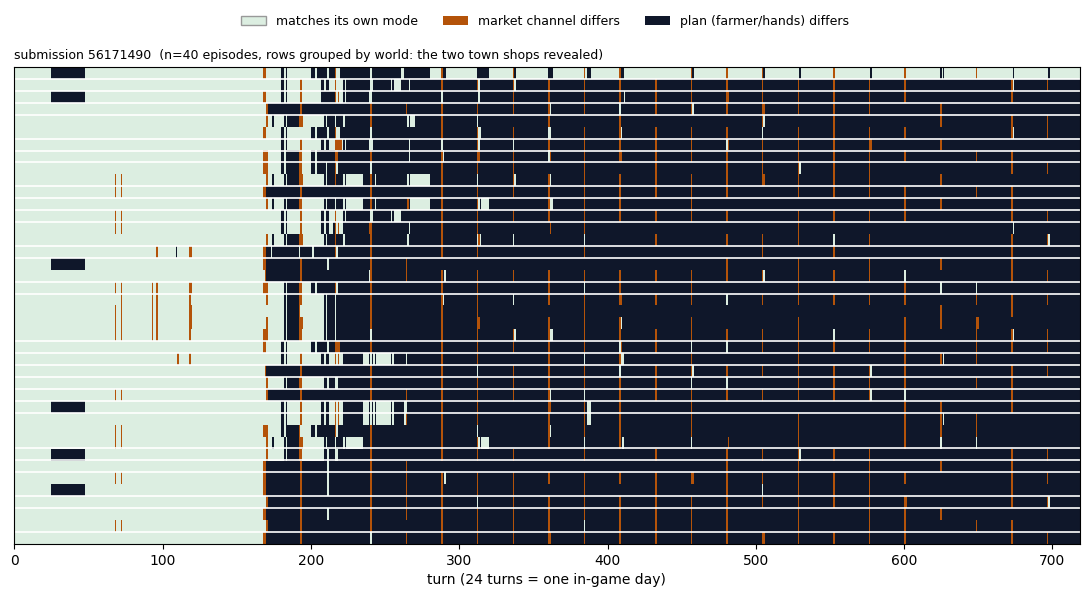

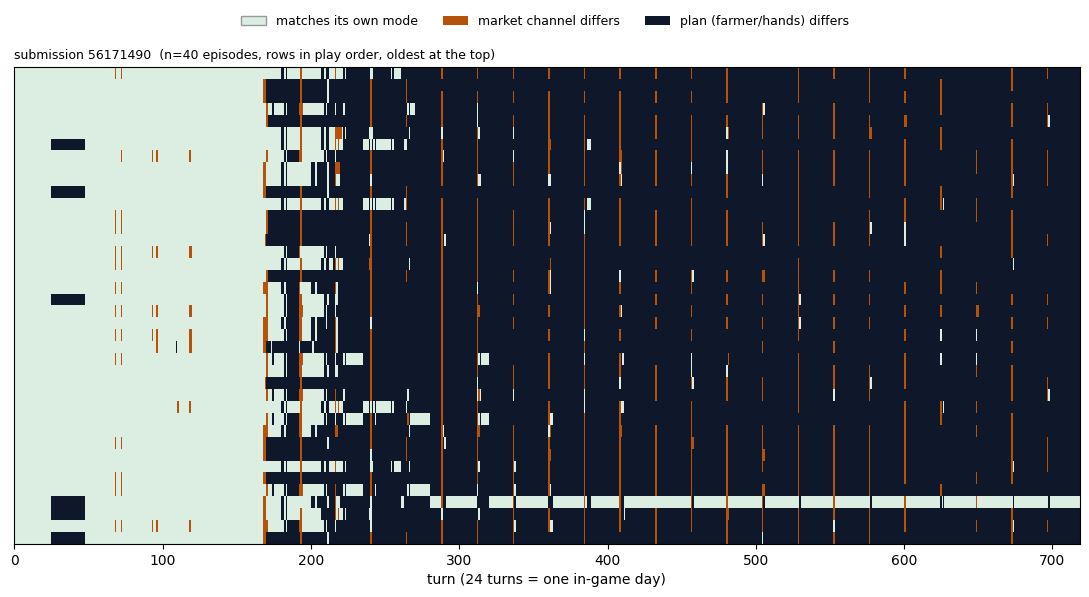

In [25]:
def stripe_panel(rr, mm, subtitle, world_lines):
    a = np.array(mm)
    h = max(2.2, a.shape[0] / 9)
    fig, ax = plt.subplots(figsize=(11, h + 1.6))
    ax.imshow(a, aspect="auto", cmap=ListedColormap([SAME, MUT, PLAN]),
              vmin=0, vmax=2, interpolation="nearest")
    if world_lines:
        prev = None
        for i, r in enumerate(rr):
            if prev is not None and r["pair"] != prev:
                ax.axhline(i - 0.5, color="white", lw=1.2)
            prev = r["pair"]
    ax.set_yticks([]); ax.grid(False)
    ax.set_xlabel("turn (24 turns = one in-game day)")
    ax.set_title(f"submission {SUBMISSION_ID}  (n={a.shape[0]} episodes, {subtitle})",
                 fontsize=9, loc="left")
    fig.legend(handles=[
        Patch(facecolor=SAME, edgecolor="0.6", label="matches its own mode"),
        Patch(facecolor=MUT, label="market channel differs"),
        Patch(facecolor=PLAN, label="plan (farmer/hands) differs")],
        fontsize=9, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.99))
    plt.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()

stripe_panel(rows, mat, "rows grouped by world: the two town shops revealed", True)
chrono = sorted(range(len(rows)), key=lambda i: rows[i]["episode"])
stripe_panel([rows[i] for i in chrono], [mat[i] for i in chrono],
             "rows in play order, oldest at the top", False)

## 3. How to read the panels

The chart comes twice, because two orderings answer two different questions.

A **WORLD** here is the ordered pair of the FIRST TWO town shops the episode revealed, at turns 72 and 144. The town keeps unlocking a shop every three days, up to nine in a season, so two is not a magic number and deserves its justification:

* **Timing against sunk cost.** Land, herd and construction commit in the first week, so a shop revealed on day 3 or 6 can still steer them; one revealed on day 9 or later meets a farm that is mostly committed.
* **The marginal is measured, not assumed.** The strongest public router conditions on exactly these two, and its author priced the second branch at **+0.136 points of rating per game** over his own 24,000-game census.
* **Each further branch multiplies the space by eight.** Two shops make 64 worlds, three make 512, and the episodes available to validate a plan per world collapse accordingly.

Whether a third branch pays is **an open question, not a settled no**.

* The **first panel** groups rows by world, white lines between worlds, so route structure reads as blocks instead of noise.
* The **second panel** puts the same rows in play order, oldest at the top: the view where TIME shows, a submission that changed behaviour mid-life, a mirror population arriving, or matchmaking walking you into a different neighbourhood of opponents.

How to read what you got.

A solid green panel is a pure replay: the submission plays the same recorded game every time, and everything it will ever do is already public in its first episode.

A green panel with amber columns is a script with repairs: one plan, and a market channel that answers the day. Most of the field looks like this.

A green opening that forks into navy blocks at turns 72 or 144 is a shop router: the plan itself is chosen by which shops the town revealed, and each block is one world's route. The white lines separate shop pairs precisely so this reads as structure instead of noise.

A panel that goes navy as the season ages, inside the same shop pair, is a live policy: the plan itself responds to the opponent, and no single recording of it tells you what it will do next time.

## 4. Classification

The texture has a name, and one number lies about a router, so I classify twice.

**GLOBAL** compares all episodes together. **WITHIN-WORLD** groups episodes by the shop pair the town actually revealed and compares only inside each group. A shop router forks its plan at turns 72 and 144 with the draw, so it reads as wildly adaptive globally while each world's games are near-identical. A genuinely live policy diverges inside a world too. **The gap between the two readings is the diagnosis.**

GLOBAL: ADAPTIVE  (varying 80.9%, first divergence t=25, channels {'farmer': 526, 'hands': 551, 'market': 505})
within-world verdict: {'ADAPTIVE': 8}


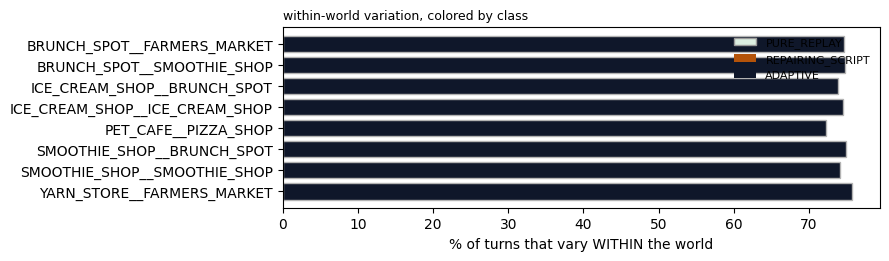

,world,n,cls,vary,first
0,BAKERY__BAKERY,1,(one episode),,
1,BAKERY__FARMERS_MARKET,1,(one episode),,
2,BAKERY__ICE_CREAM_SHOP,1,(one episode),,
3,BAKERY__YARN_STORE,1,(one episode),,
4,BRUNCH_SPOT__FARMERS_MARKET,2,ADAPTIVE,74.7%,168
5,BRUNCH_SPOT__ICE_CREAM_SHOP,1,(one episode),,
6,BRUNCH_SPOT__PIZZA_SHOP,1,(one episode),,
7,BRUNCH_SPOT__SMOOTHIE_SHOP,2,ADAPTIVE,74.8%,68
8,BRUNCH_SPOT__YARN_STORE,1,(one episode),,
9,FARMERS_MARKET__ICE_CREAM_SHOP,1,(one episode),,


In [26]:
CHANNELS = ("farmer", "hands", "market")

def compare_streams(streams):
    n = min(len(s) for s in streams)
    chan = {c: 0 for c in CHANNELS}
    first = None
    varying = 0
    for t in range(n):
        acts = [canon(s[t]) for s in streams]
        if len(set(acts)) > 1:
            varying += 1
            if first is None:
                first = t
            for i, c in enumerate(CHANNELS):
                if len({a[i] for a in acts}) > 1:
                    chan[c] += 1
    return dict(turns=n, varying=varying, frac=varying / max(1, n),
                first=first, chan=chan)

def classify(c):
    plan_moves = c["chan"]["farmer"] + c["chan"]["hands"]
    if c["varying"] == 0:
        return "PURE_REPLAY"
    if plan_moves == 0 and c["frac"] < 0.25:
        return "REPAIRING_SCRIPT"
    if c["frac"] < 0.10:
        return "REPAIRING_SCRIPT"
    return "ADAPTIVE"

g = compare_streams([r["stream"] for r in rows])
gcls = classify(g)
print(f"GLOBAL: {gcls}  (varying {g['frac']:.1%}, first divergence t={g['first']}, channels {g['chan']})")
if gcls == "ADAPTIVE" and g["first"] is not None and 70 <= g["first"] <= 146:
    print("  a plan fork in t=[72,144] tracks the shop draw: that is ROUTING; read the table below")

by_pair = collections.defaultdict(list)
for r in rows:
    by_pair[r["pair"]].append(r["stream"])
tbl = []
for pr in sorted(by_pair):
    ss = by_pair[pr]
    if len(ss) < 2:
        tbl.append(dict(world=pr, n=1, cls="(one episode)", vary="", first=""))
        continue
    cw = compare_streams(ss)
    tbl.append(dict(world=pr, n=len(ss), cls=classify(cw), varyf=cw["frac"],
                    vary=f"{cw['frac']:.1%}", first=cw["first"]))
wtab = pd.DataFrame(tbl)
verdict = collections.Counter(t["cls"] for t in tbl if t["n"] >= 2)
print(f"within-world verdict: {dict(verdict)}")
multi = [t for t in tbl if t["n"] >= 2]
if multi:
    colmap = {"PURE_REPLAY": SAME, "REPAIRING_SCRIPT": MUT, "ADAPTIVE": PLAN}
    figC, axC = plt.subplots(figsize=(9, max(2.2, 0.34 * len(multi))))
    axC.barh([t["world"] for t in multi], [t["varyf"] * 100 for t in multi],
             color=[colmap[t["cls"]] for t in multi], edgecolor="0.7")
    axC.set_xlabel("% of turns that vary WITHIN the world")
    axC.invert_yaxis()
    axC.set_title("within-world variation, colored by class", fontsize=9, loc="left")
    axC.legend(handles=[Patch(facecolor=SAME, edgecolor="0.6", label="PURE_REPLAY"),
                        Patch(facecolor=MUT, label="REPAIRING_SCRIPT"),
                        Patch(facecolor=PLAN, label="ADAPTIVE")],
               frameon=False, fontsize=8)
    plt.tight_layout(); plt.show()
# errors="ignore": with few episodes no world repeats, wtab comes
# back empty and this raised KeyError on the column it was dropping.
# A brand-new submission is exactly the case with few episodes, and
# it is the reader this notebook invites.
wtab.drop(columns=["varyf"], errors="ignore")

What each class means for the agent you are looking at.

* **PURE_REPLAY**: byte-identical streams. Everything this submission will ever do is already public in its first episode, and anyone can replay it verbatim.
* **REPAIRING_SCRIPT**: one plan, small localised differences, usually market-only. Most of the field looks like this, and the plan half is still harvestable.
* **ADAPTIVE**: the plan itself moves between episodes of the SAME world. A recording of it answered one opponent and one seed, and replaying it plays a game it never played.

One honest limit: two episodes differ both because the agent reacted and because the seed differs, and streams alone cannot fully separate the two. That is exactly why the within-world grouping exists, it removes the largest seed effect there is, the shop draw, before reading anything as reactivity.

## 5. Kinship with the opponents

A duel leaves both streams in the replay, so the same download that x-rayed you also holds every opponent you faced, and kinship between agents is measurable from actions alone.

Three numbers per opponent:

* **PLAN agreement**, the fraction of turns where farmer and hands are identical, finds the family: shared chassis, shared notebook, shared route.
* **WHOLE agreement** adds the market channel, and 1.000 there means you two played the same recorded game.
* **The BARCODE** is thirty per-day signatures of the plan channel over hours 1 to 4 of each day, the resynchronisation anchor this engine gives every morning, and the first differing band localises WHERE two related routes fork, to the day.

An opponent at plan 1.000 is **your mirror**: it runs your exact lineage, and everything you will do is as public to it as its play is to you. High plan with a low whole is a sibling that changed only its selling. Agreement confined to the first two or three days is not kinship at all, nothing observable differs before turn 48 in this game, so every agent agrees at dawn.

0 mirror games (plan >= 0.95), 0 sibling games (0.50-0.95), 40 unrelated


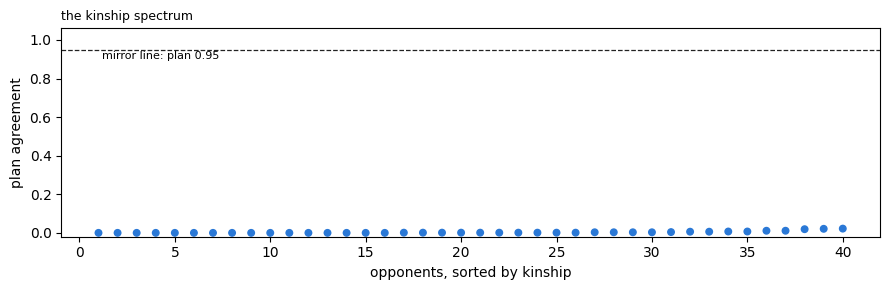

,opponent,submission,episode,res,margin,plan,whole,bands,fork_day
0,Spacejam,56080558,107927581,L,"-24,494",0.022000,0.017000,0/30,0
1,ayushk_empire,55498758,108125266,W,"+20,894",0.021000,0.014000,0/30,0
2,Karthikeya Thatipamula,56092506,107937589,L,"-18,315",0.019000,0.014000,0/30,0
3,HandsOffMyBigMelons,55491887,107940579,W,"+12,081",0.011000,0.011000,0/30,0
4,Bharathms1902,55331983,107968517,L,"-9,809",0.011000,0.004000,0/30,0
5,bomboclat,55871541,107934574,W,"+15,576",0.007000,0.004000,0/30,0
6,Jiawei Zhao,56168793,108000478,W,"+12,514",0.007000,0.000000,0/30,0
7,jiangletian,55731407,107929585,W,"+46,451",0.006000,0.000000,0/30,0
8,Koiiiiiopen,55329136,107932562,W,"+33,070",0.006000,0.006000,0/30,0
9,astro,55654212,107949564,L,"-1,082",0.004000,0.000000,0/30,0


In [27]:
import hashlib
STRUCT = {"HIRE", "BUY_LAND", "BUY_ANIMAL"}
PROV = {"BUY_SEED", "BUY_PRODUCT"}

def band(stream, day):
    sig = []
    for h in range(1, 5):
        t = day * 24 + h
        a = stream[t] if t < len(stream) else PASS
        m = [[o[0], o[1] if len(o) > 1 else None]
             for o in (a.get("market") or []) if o and o[0] in STRUCT | PROV]
        sig.append([a.get("farmer"), a.get("hands"), m])
    return hashlib.md5(json.dumps(sig, sort_keys=True).encode()).hexdigest()

def barcode(stream):
    return [band(stream, d) for d in range(30)]

kin = []
for r in rows:
    mine_c = [canon(a) for a in r["stream"]]
    opp_c = [canon(a) for a in r["opp_stream"]]
    n = len(mine_c)
    plan = sum(1 for a, b in zip(mine_c, opp_c) if a[:2] == b[:2]) / n
    whole = sum(1 for a, b in zip(mine_c, opp_c) if a == b) / n
    mb, ob = barcode(r["stream"]), barcode(r["opp_stream"])
    shared = sum(1 for x, y in zip(mb, ob) if x == y)
    fork = next((d for d, (x, y) in enumerate(zip(mb, ob)) if x != y), None)
    res = "W" if r["margin"] > 0 else ("L" if r["margin"] < 0 else "T")
    kin.append(dict(opponent=r["opp"], submission=r["opp_sub"], episode=r["episode"],
                    res=res, margin=r["margin"], plan=round(plan, 3),
                    whole=round(whole, 3), bands=f"{shared}/30", fork_day=fork))
kin.sort(key=lambda k: -k["plan"])
mirrors = [k for k in kin if k["plan"] >= 0.95]
siblings = [k for k in kin if 0.5 <= k["plan"] < 0.95]
print(f"{len(mirrors)} mirror games (plan >= 0.95), {len(siblings)} sibling games "
      f"(0.50-0.95), {len(kin) - len(mirrors) - len(siblings)} unrelated")
if mirrors:
    mm = [k["margin"] for k in mirrors]
    print(f"against mirrors: {sum(1 for x in mm if x > 0)}W-"
          f"{sum(1 for x in mm if x < 0)}L-{sum(1 for x in mm if x == 0)}T, "
          f"margins {sorted(mm)}")
figK, axK = plt.subplots(figsize=(9, 3))
ks = sorted(kin, key=lambda k: k["plan"])
axK.scatter(range(1, len(ks) + 1), [k["plan"] for k in ks],
            c=["#c44536" if k["plan"] >= 0.95 else "#2a78d6" for k in ks], s=22)
axK.axhline(0.95, color="#222", lw=0.9, ls="--")
axK.text(1.2, 0.90, "mirror line: plan 0.95", fontsize=8)
axK.set_xlabel("opponents, sorted by kinship")
axK.set_ylabel("plan agreement")
axK.set_ylim(-0.02, 1.06)
axK.set_title("the kinship spectrum", fontsize=9, loc="left")
plt.tight_layout(); plt.show()
kdf = pd.DataFrame(kin)

def _kin_tint(row):
    a = 0.04 + 0.32 * min(max(row["plan"], 0.0), 1.0)
    return [f"background-color: rgba(180, 83, 9, {a:.2f})"] * len(row)

kdf.style.apply(_kin_tint, axis=1).format({"margin": "{:+,.0f}"})

And the opponents themselves fall into **genetic groups**. Two rivals from different worlds can still share a lineage, they just fork at the shop branches, so I group them by plan agreement over the OPENING window, the turns before the second branch at t=144, at a 0.98 threshold: connected components of "plays the same opening". Per group, the statistics that matter in a duel: how often you met it, the record against it, and the margins.

The group your own lineage belongs to is marked. A large group with a negative median margin is a population problem, not a bad day; a group you only tie is your own chassis looking back at you.

38 genetic groups among 40 opponents (1 with 2+ games, 37 singletons)


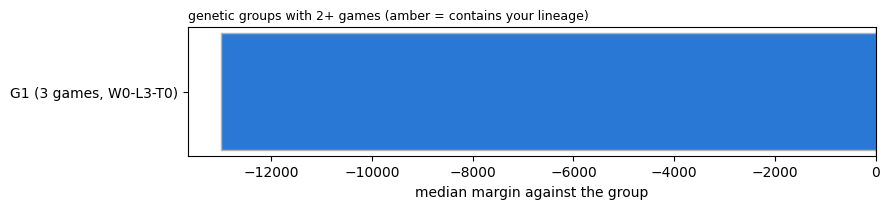

,group,yours,games,submissions,lead,record,margin_med,worst,best,plan_to_you
0,G1,,3,3,lossvis,W0-L3-T0,-13006,-24197,-7476,0.000
1,G2,,1,1,Zhenghongshuang,W0-L1-T0,-42270,-42270,-42270,0.001
2,G3,,1,1,HexTex,W0-L1-T0,-17166,-17166,-17166,0.000
3,G4,,1,1,Pawan Rama Mali,W0-L1-T0,-45899,-45899,-45899,0.001
4,G5,,1,1,Logan Seitz,W0-L1-T0,-15196,-15196,-15196,0.001
5,G6,,1,1,Spacejam,W0-L1-T0,-24494,-24494,-24494,0.022
6,G7,,1,1,Sarah Ng,W0-L1-T0,-18627,-18627,-18627,0.001
7,G8,,1,1,jiangletian,W1-L0-T0,46451,46451,46451,0.006
8,G9,,1,1,Lê Ngọc Lâm,W0-L1-T0,-11147,-11147,-11147,0.000
9,G10,,1,1,JJN8825,W1-L0-T0,20439,20439,20439,0.001


In [28]:
PRE = 144
pre_c = [[canon(a)[:2] for a in r["opp_stream"][:PRE]] for r in rows]

def pre_agree(i, j):
    return sum(1 for a, b in zip(pre_c[i], pre_c[j]) if a == b) / PRE

parent = list(range(len(rows)))
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x
for i in range(len(rows)):
    for j in range(i + 1, len(rows)):
        if pre_agree(i, j) >= 0.98:
            parent[find(i)] = find(j)

groups = collections.defaultdict(list)
for i in range(len(rows)):
    groups[find(i)].append(i)

mirror_eps = {k["episode"] for k in kin if k["plan"] >= 0.95}
gtab = []
for gid, idxs in sorted(groups.items(), key=lambda kv: -len(kv[1])):
    ms = sorted(rows[i]["margin"] for i in idxs)
    subs = {rows[i]["opp_sub"] for i in idxs}
    names = [rows[i]["opp"] for i in idxs]
    plans = sorted(k["plan"] for k in kin if k["episode"] in {rows[i]["episode"] for i in idxs})
    Wg = sum(1 for m in ms if m > 0); Lg = sum(1 for m in ms if m < 0)
    gtab.append(dict(
        group=f"G{len(gtab) + 1}",
        yours="<- your lineage" if any(rows[i]["episode"] in mirror_eps for i in idxs) else "",
        games=len(idxs), submissions=len(subs),
        lead=collections.Counter(names).most_common(1)[0][0],
        record=f"W{Wg}-L{Lg}-T{len(ms) - Wg - Lg}",
        margin_med=ms[len(ms) // 2], worst=ms[0], best=ms[-1],
        plan_to_you=plans[len(plans) // 2] if plans else None))
big = [g for g in gtab if g["games"] >= 2]
print(f"{len(gtab)} genetic groups among {len(rows)} opponents "
      f"({len(big)} with 2+ games, {len(gtab) - len(big)} singletons)")
figG, axG = plt.subplots(figsize=(9, max(2.2, 0.5 * len(big))))
labels = [f'{g["group"]} ({g["games"]} games, {g["record"]})' for g in big]
axG.barh(labels, [g["margin_med"] for g in big],
         color=[MUT if g["yours"] else "#2a78d6" for g in big], edgecolor="0.7")
axG.axvline(0, color="#222", lw=0.9)
axG.invert_yaxis()
axG.set_xlabel("median margin against the group")
axG.set_title("genetic groups with 2+ games (amber = contains your lineage)",
              fontsize=9, loc="left")
plt.tight_layout(); plt.show()
pd.DataFrame(gtab)

## 6. The macroeconomic x-ray

The stripes show WHAT you play; the macroeconomic x-ray shows what your economy DID. When the second quadrant arrived, how much CARE the herd got, whether the endgame left tiles fallow and stock stranded at the bell, and how money accumulated day by day, one line per episode.

The reference column is the shape of the number one **as of my 2026-08-30 capture**, measured in [my macroeconomic x-ray of the meta](https://www.kaggle.com/code/destbreso/a-macroeconomic-x-ray-of-the-kaggriculture-meta), and a rank is a timestamp, not a property, so re-read it there if you are far from that date: second quadrant on **day 5**, **seven cows**, about **280 CARE actions**, and it leaves **13 tiles fallow** late and **442 dollars stranded**, so those two are not targets, they are what the strongest agent happens to tolerate.

macro profile, median [p10, p90]; ref = the measured #1 shape
  2nd quadrant, day                      7 [7, 7]    ref 5
  care actions                         229 [146, 262]    ref 280
  herd bought (median)           COW 8  SHEEP 3  GOOSE 0    ref 7 COW
  endgame fallow tiles d25-29            6 [4, 8]    ref 13
  stranded $ at the bell               388 [16, 1,050]    ref 442
  pass-with-work unit-turns            410 [401, 423]    ref low
  shed-at-cap turns                      0 [0, 2]    ref 0
  floor sells (price <= 2)               2 [0, 11]    ref 0


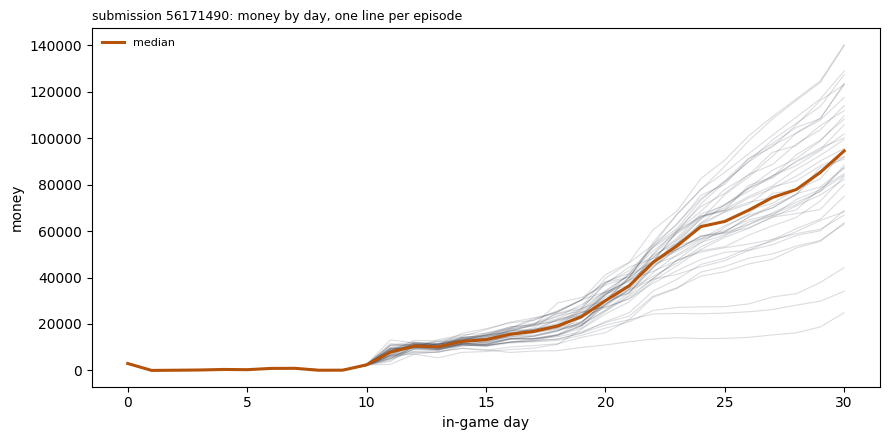

In [29]:
def q(vals, p):
    v = sorted(vals)
    return v[min(len(v) - 1, int(p * len(v)))]

M = [r["macro"] for r in rows]
herd_med = {a: q([m["herd"].get(a, 0) for m in M], 0.5) for a in ("COW", "SHEEP", "GOOSE")}

def mrow(label, vals, ref):
    vv = [v for v in vals if v is not None]
    if vv:
        print(f"  {label:<30} {q(vv, 0.5):>9,.0f} [{q(vv, 0.1):,.0f}, {q(vv, 0.9):,.0f}]    ref {ref}")

print("macro profile, median [p10, p90]; ref = the measured #1 shape")
mrow("2nd quadrant, day", [m["land2"] for m in M], "5")
mrow("care actions", [m["care"] for m in M], "280")
print(f"  {'herd bought (median)':<30} COW {herd_med['COW']}  SHEEP {herd_med['SHEEP']}  "
      f"GOOSE {herd_med['GOOSE']}    ref 7 COW")
mrow("endgame fallow tiles d25-29", [m["fallow_late"] for m in M], "13")
mrow("stranded $ at the bell", [m["stranded"] for m in M], "442")
mrow("pass-with-work unit-turns", [m["pass_work"] for m in M], "low")
mrow("shed-at-cap turns", [m["shed_cap_turns"] for m in M], "0")
mrow("floor sells (price <= 2)", [m["floor_sells"] for m in M], "0")

fig2, ax2 = plt.subplots(figsize=(9, 4.5))
days = list(range(31))
for r in rows:
    ax2.plot(days, r["macro"]["money_by_day"], color=PLAN, alpha=0.15, lw=0.8)
med = [q([r["macro"]["money_by_day"][d] for r in rows], 0.5) for d in days]
ax2.plot(days, med, color=MUT, lw=2.2, label="median")
ax2.set_xlabel("in-game day"); ax2.set_ylabel("money")
ax2.set_title(f"submission {SUBMISSION_ID}: money by day, one line per episode",
              fontsize=9, loc="left")
ax2.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

And the same farm indicators as DISTRIBUTIONS rather than points, one dot per episode, jittered, alpha so concentration reads as density. The blue cloud is the leader of my 2026-08-30 macroeconomic x-ray capture, one dot per each of its 245 real episodes, embedded here so the chart works without extra downloads; the orange cloud is the submission you are reading. Everything is a multiple of the leader median for that row, the vertical line at 1, and the thick tick above each cloud is that side's median. A row where your cloud is missing means your agent never did the thing, which for the third quadrant is itself a reading.

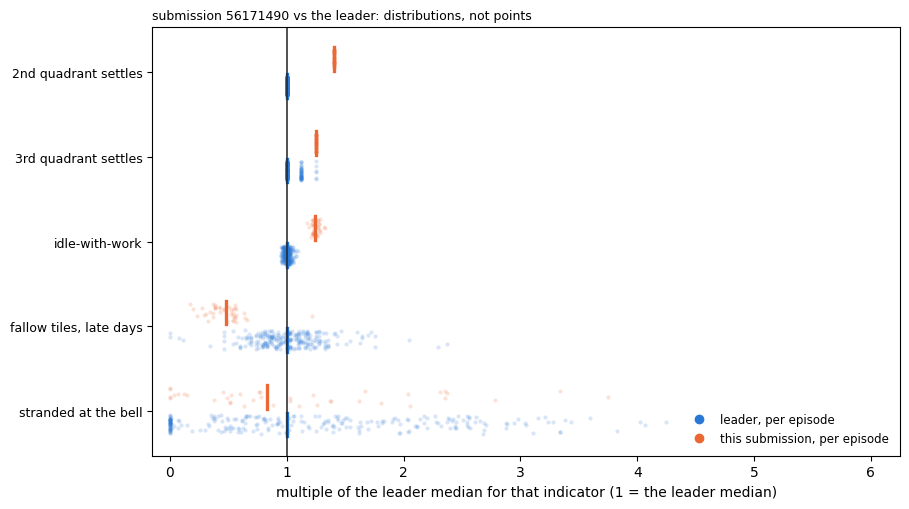

In [30]:
import random
LEADER_REF = json.loads('{"land2": [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5], "land3": [8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 9, 9, 8, 8, 8, 8, 10, 8, 8, 9, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 9, 8, 8, 8, 8, 8, 9, 9, 8, 8, 8, 9, 8, 8, 8, 8, 8, 9, 8, 9, 8, 8, 9, 8, 8, 8, 8, 9, 8, 8, 8, 8, 8, 8, 8, 9, 8, 8, 8, 8, 9, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 9, 8, 9, 8, 8, 9, 9, 8, 8, 8, 8, 9, 8, 8, 8, 9, 8, 8, 8, 8, 9, 8, 9, 8, 9, 8, 9, 8, 8, 9, 8, 10, 8, 9, 8, 8, 8, 9, 8, 8, 8, 9, 10, 10, 8, 8, 8, 8, 8, 8, 8, 8, 9, 8, 8, 10, 8, 8, 8, 8, 9, 9, 8, 8, 8, 8, 8, 8, 8, 8, 9, 9, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 10, 8, 8, 8, 8, 8, 8, 8, 8, 9, 9, 8, 9, 8, 8, 9, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 9, 9, 8, 8, 9, 9, 8, 8, 8, 8, 9, 8, 9, 9, 8, 8, 8], "pass_work": [335, 339, 334, 326, 335, 336, 326, 336, 332, 330, 339, 346, 331, 340, 319, 331, 332, 322, 323, 324, 325, 329, 333, 337, 339, 342, 321, 332, 331, 317, 322, 320, 329, 325, 329, 324, 316, 320, 326, 328, 324, 322, 323, 320, 331, 321, 322, 316, 321, 323, 319, 325, 315, 328, 319, 326, 318, 314, 336, 316, 321, 321, 318, 321, 317, 325, 329, 319, 314, 317, 324, 331, 318, 320, 322, 324, 325, 328, 320, 316, 330, 317, 319, 313, 327, 325, 325, 323, 334, 318, 314, 327, 326, 322, 325, 317, 332, 317, 316, 324, 328, 313, 324, 316, 317, 328, 341, 337, 331, 325, 348, 341, 338, 328, 339, 337, 333, 331, 331, 328, 335, 328, 326, 333, 326, 336, 340, 330, 324, 341, 336, 329, 332, 332, 347, 326, 356, 336, 348, 338, 327, 331, 329, 326, 325, 333, 327, 337, 339, 331, 326, 329, 326, 331, 330, 343, 339, 320, 337, 324, 334, 335, 343, 328, 331, 330, 332, 335, 335, 351, 326, 332, 327, 321, 336, 332, 330, 333, 341, 344, 324, 328, 328, 340, 331, 337, 333, 328, 345, 332, 338, 338, 338, 330, 333, 331, 324, 347, 355, 341, 335, 348, 335, 348, 330, 341, 326, 328, 330, 336, 332, 330, 337, 332, 356, 328, 335, 330, 336, 333, 340, 339, 333, 325, 361, 339, 332, 329, 338, 333, 339, 330, 330, 348, 329, 336, 353, 340, 348, 340, 346, 328, 329, 331, 327], "fallow_late": [9.0, 30.8, 15.0, 9.0, 11.2, 16.6, 9.6, 17.6, 10.2, 10.6, 22.8, 12.4, 16.0, 21.4, 0, 21.4, 10.6, 9.6, 15.2, 12.2, 11.4, 7.8, 16.2, 14.2, 11.2, 8.4, 13.0, 13.2, 10.6, 7.4, 9.8, 14.2, 16.2, 13.0, 16.6, 16.2, 12.0, 13.0, 12.8, 14.2, 10.2, 14.0, 11.2, 13.0, 12.6, 12.0, 7.8, 12.0, 8.5, 11.0, 13.6, 1.0, 12.4, 13.0, 9.0, 12.8, 15.8, 15.2, 8.6, 10.8, 15.2, 16.6, 11.4, 13.4, 10.4, 4.5, 15.0, 18.4, 10.8, 15.2, 12.0, 14.4, 13.0, 14.4, 15.4, 12.2, 14.0, 16.6, 11.6, 10.6, 14.4, 14.6, 13.0, 16.2, 12.0, 17.2, 10.6, 7.6, 15.0, 10.0, 15.6, 13.4, 15.6, 13.2, 17.6, 13.4, 14.4, 11.2, 14.0, 13.4, 11.8, 10.8, 12.4, 17.0, 10.4, 10.4, 10.4, 12.6, 9.8, 10.8, 13.4, 12.8, 14.8, 11.4, 14.6, 17.2, 16.0, 17.2, 10.0, 10.6, 10.2, 8.0, 12.8, 15.8, 11.2, 15.0, 14.0, 15.4, 9.0, 14.4, 10.6, 11.8, 11.0, 20.0, 12.8, 9.0, 19.0, 11.2, 17.4, 11.8, 14.4, 13.4, 12.8, 9.6, 8.8, 15.2, 14.4, 8.5, 13.8, 17.2, 12.0, 15.4, 11.6, 6.0, 10.2, 14.6, 26.6, 11.8, 11.8, 11.0, 14.8, 19.6, 29.8, 10.8, 11.0, 15.6, 11.4, 14.6, 15.2, 0, 12.2, 17.6, 12.4, 10.6, 14.8, 1.5, 13.8, 16.6, 15.0, 15.6, 6.0, 15.0, 9.8, 21.2, 16.2, 10.4, 9.6, 10.8, 7.0, 11.0, 10.8, 13.4, 10.4, 9.8, 13.2, 13.6, 8.4, 22.0, 9.6, 18.6, 12.0, 13.2, 13.4, 8.8, 11.6, 16.8, 7.0, 14.4, 16.0, 15.4, 16.6, 13.0, 13.4, 13.6, 14.2, 11.4, 14.4, 13.4, 13.2, 17.6, 14.0, 15.4, 14.0, 7.8, 6.0, 18.2, 14.8, 8.8, 17.2, 11.0, 22.4, 11.4, 6.0, 22.8, 11.8, 18.6, 15.2, 16.6, 13.0, 13.4, 20.8, 10.0, 16.2, 12.2, 11.6], "stranded": [1796, 0, 0, 1129, 132, 616, 1124, 0, 231, 385, 442, 663, 369, 357, 0, 172, 803, 260, 0, 451, 242, 1276, 0, 723, 405, 624, 612, 238, 929, 316, 1591, 1133, 192, 579, 650, 647, 900, 714, 1125, 902, 17, 324, 285, 0, 451, 467, 1002, 271, 681, 40, 408, 0, 329, 183, 282, 637, 2, 276, 204, 112, 168, 0, 1083, 0, 716, 336, 144, 0, 1375, 160, 330, 330, 1, 0, 256, 217, 1878, 0, 4, 320, 301, 346, 0, 638, 0, 220, 64, 1107, 0, 1477, 0, 197, 0, 148, 288, 1016, 0, 288, 35, 256, 905, 226, 270, 3, 598, 1692, 0, 1188, 896, 1448, 946, 1196, 973, 357, 1071, 405, 810, 961, 1184, 1136, 227, 1054, 1047, 470, 7, 358, 1495, 0, 1394, 682, 1008, 1476, 1271, 0, 841, 0, 440, 1155, 589, 750, 193, 156, 1174, 782, 1157, 439, 1069, 0, 459, 467, 1125, 32, 963, 408, 1026, 183, 0, 282, 1346, 852, 30, 272, 0, 571, 632, 351, 364, 371, 1272, 0, 0, 249, 804, 1517, 378, 635, 550, 710, 1080, 0, 411, 760, 526, 0, 843, 1083, 972, 867, 84, 1316, 936, 1420, 1302, 1429, 297, 1780, 168, 0, 0, 168, 582, 870, 668, 666, 656, 1130, 495, 1345, 1053, 789, 219, 0, 1080, 495, 744, 418, 1088, 0, 564, 0, 524, 0, 587, 862, 0, 720, 615, 936, 1, 1060, 0, 0, 210, 0, 507, 424, 870, 212, 0, 622, 410, 1190, 599, 500, 551]}')

dot_rows = [("2nd quadrant settles", "land2"),
            ("3rd quadrant settles", "land3"),
            ("idle-with-work", "pass_work"),
            ("fallow tiles, late days", "fallow_late"),
            ("stranded at the bell", "stranded")]

def med(v):
    s = sorted(v); n = len(s)
    return s[n // 2] if n % 2 else (s[n // 2 - 1] + s[n // 2]) / 2

rng = random.Random(11)
XMAX = 6.0
fig4, ax4 = plt.subplots(figsize=(9.2, 5.2))
for i, (lab, key) in enumerate(dot_rows):
    lm = med(LEADER_REF[key]) or 1.0
    mine_vals = [m[key] for m in M if m.get(key) is not None]
    for vals, colour, dy in ((LEADER_REF[key], "#2a78d6", +0.16),
                             (mine_vals, "#eb6834", -0.16)):
        if not vals:
            continue
        xs = [min(v / lm, XMAX) for v in vals]
        ys = [i + dy + rng.uniform(-0.11, 0.11) for _ in xs]
        ax4.scatter(xs, ys, s=9, color=colour, alpha=0.18, linewidths=0)
        mm = min(med(vals) / lm, XMAX)
        ax4.plot([mm, mm], [i + dy - 0.14, i + dy + 0.14], color=colour, lw=2.4)
ax4.axvline(1.0, color="#222", lw=1.1)
ax4.set_yticks(range(len(dot_rows)))
ax4.set_yticklabels([r[0] for r in dot_rows], fontsize=9)
ax4.invert_yaxis()
ax4.set_xlim(-0.15, XMAX + 0.25)
ax4.set_xlabel("multiple of the leader median for that indicator (1 = the leader median)")
ax4.set_title(f"submission {SUBMISSION_ID} vs the leader: distributions, not points",
              fontsize=9, loc="left")
from matplotlib.lines import Line2D
ax4.legend(handles=[Line2D([], [], marker="o", ls="", color="#2a78d6", label="leader, per episode"),
                    Line2D([], [], marker="o", ls="", color="#eb6834", label="this submission, per episode")],
           frameon=False, loc="lower right", fontsize=8.5)
plt.tight_layout(); plt.show()

### Actions on money, and the craters under the rival

The bank curve above says *when* the money arrived. This chart says **what was done to make it move**, on the single most decisive episode of the sample (the largest margin either way): both money curves, every market order as a marker **sized by its dollar weight** (circle sell, square structural purchase, triangle other), so the buys that financed the season and the sells that paid for them sit on the curve they moved.

And the market is shared, so a sell is also a **weapon**. When one side dumps a product the book reprices it for both. A shaded span marks a **crater**: one side's large sell drops a product's price and the other side sells the same product into the depressed window within a day. **Red: the rival sold into our crater. Blue: we sold into theirs.** The damage figure is first-order, victim quantity times the price drop they ate, so read it as the size of the hole rather than as a causal transfer. The lower panel shows the price paths of exactly the products the craters touched.


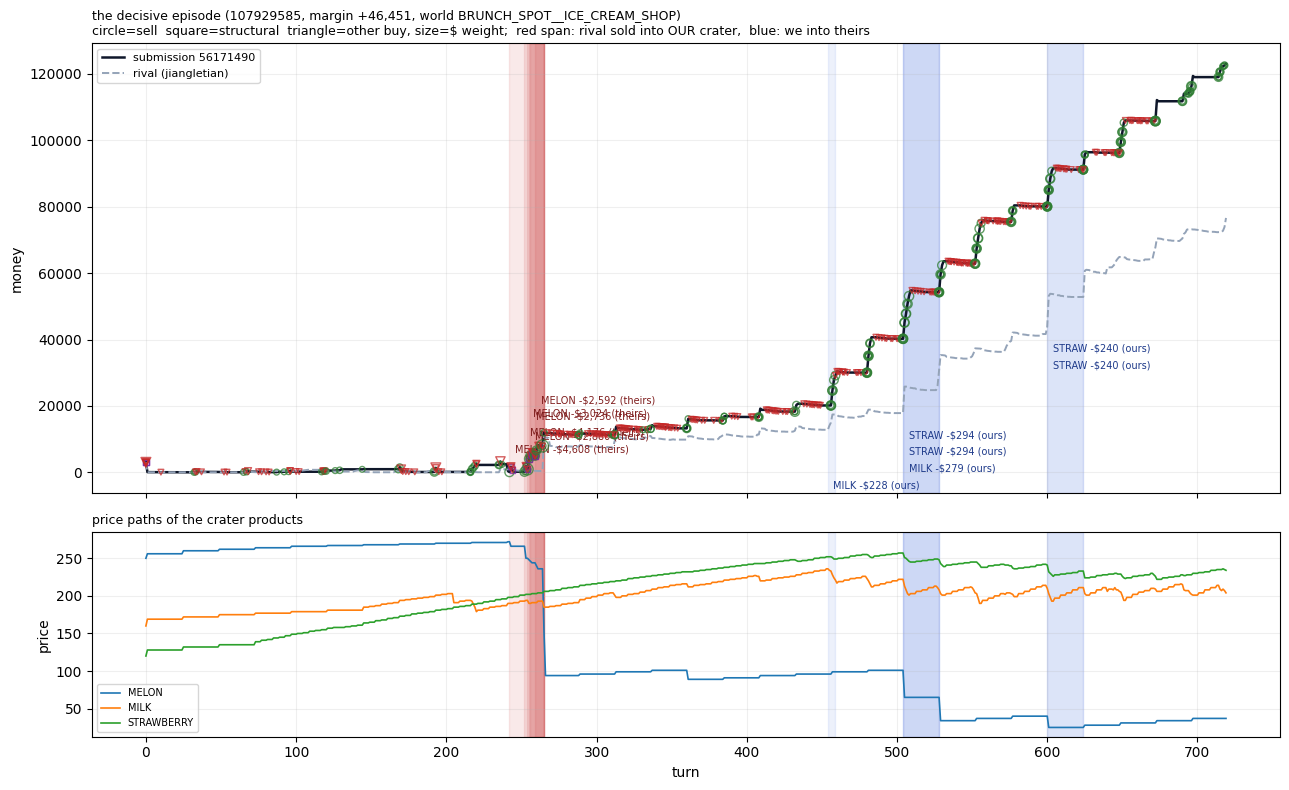

craters dug by us that the rival sold into: MELON -$4,608, MELON -$4,176, MELON -$3,024, MELON -$2,880, MELON -$2,736, MELON -$2,592
craters we sold into: STRAWBERRY -$294, STRAWBERRY -$294, MILK -$279, STRAWBERRY -$240, STRAWBERRY -$240, MILK -$228


In [31]:
def _mf_events(stream, prices_t):
    out = []
    for t, act in enumerate(stream):
        if not isinstance(act, dict): continue
        for m in (act.get("market") or []):
            if not (isinstance(m, list) and len(m) >= 2): continue
            qty = int(m[2]) if len(m) >= 3 and str(m[2]).lstrip("-").isdigit() else 1
            px = (prices_t[t] or {}).get(m[1], 0)
            out.append(dict(t=t, verb=m[0], prod=m[1], qty=qty, px=px, value=qty*px))
    return out

def _mf_craters(sellers, victims, prices_t, window=24, top=60):
    out = []
    for e in sorted((x for x in sellers if x["verb"] == "SELL"),
                    key=lambda x: -x["value"])[:top]:
        p0 = (prices_t[e["t"]] or {}).get(e["prod"], 0)
        later = [o for o in victims if o["verb"] == "SELL" and o["prod"] == e["prod"]
                 and e["t"] < o["t"] <= e["t"] + window]
        if not later: continue
        dmg = sum(o["qty"] * max(0, p0 - o["px"]) for o in later)
        if dmg <= 0: continue
        out.append(dict(t0=e["t"], t1=max(o["t"] for o in later), prod=e["prod"],
                        dmg=dmg))
    out.sort(key=lambda c: -c["dmg"])
    return out

_mf_r = max(rows, key=lambda r: abs(r["margin"]))
_mf_T = len(_mf_r["money_me"])
_mf_me = _mf_events(_mf_r["stream"], _mf_r["prices_t"])
_mf_op = _mf_events(_mf_r["opp_stream"], _mf_r["prices_t"])
_mf_ours   = _mf_craters(_mf_me, _mf_op, _mf_r["prices_t"])[:6]
_mf_theirs = _mf_craters(_mf_op, _mf_me, _mf_r["prices_t"])[:6]

_mf_fig, (_mf_ax, _mf_axp) = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                                          gridspec_kw={"height_ratios": [2.2, 1]})
_mf_xs = list(range(_mf_T))
_mf_ax.plot(_mf_xs, _mf_r["money_me"], color="#0F172A", lw=1.8,
            label=f"submission {SUBMISSION_ID}")
_mf_ax.plot(_mf_xs, _mf_r["money_op"], color="#94A3B8", lw=1.4, ls="--",
            label=f"rival ({_mf_r['opp']})")
for _mf_e in _mf_me:
    if _mf_e["verb"] == "SELL": _mf_c, _mf_mk = "#2E7D32", "o"
    elif _mf_e["verb"] in ("BUY_LAND", "BUY_ANIMAL", "HIRE"): _mf_c, _mf_mk = "#7B1FA2", "s"
    else: _mf_c, _mf_mk = "#C62828", "v"
    _mf_t = min(_mf_e["t"], _mf_T - 1)
    _mf_ax.scatter(_mf_t, _mf_r["money_me"][_mf_t], s=16 + _mf_e["value"] / 60,
                   marker=_mf_mk, facecolors="none", edgecolors=_mf_c,
                   linewidths=1.0, alpha=0.75, zorder=4)
for _mf_i, _mf_cr in enumerate(_mf_ours):
    _mf_ax.axvspan(_mf_cr["t0"], _mf_cr["t1"], color="#C62828", alpha=0.10)
    _mf_ax.annotate(f"{_mf_cr['prod'][:5]} -${_mf_cr['dmg']:,.0f} (theirs)",
                    (_mf_cr["t0"], _mf_r["money_me"][min(_mf_cr["t0"], _mf_T-1)]),
                    textcoords="offset points", xytext=(4, 14 + (_mf_i % 3) * 12),
                    fontsize=7, color="#7f1d1d")
for _mf_i, _mf_cr in enumerate(_mf_theirs):
    _mf_ax.axvspan(_mf_cr["t0"], _mf_cr["t1"], color="#1D4ED8", alpha=0.08)
    _mf_ax.annotate(f"{_mf_cr['prod'][:5]} -${_mf_cr['dmg']:,.0f} (ours)",
                    (_mf_cr["t0"], _mf_r["money_op"][min(_mf_cr["t0"], _mf_T-1)]),
                    textcoords="offset points", xytext=(4, -18 - (_mf_i % 3) * 12),
                    fontsize=7, color="#1e3a8a")
_mf_ax.legend(fontsize=8, loc="upper left"); _mf_ax.grid(alpha=0.2)
_mf_ax.set_ylabel("money")
_mf_ax.set_title(f"the decisive episode ({_mf_r['episode']}, margin {_mf_r['margin']:+,.0f}, "
                 f"world {_mf_r['pair']})\ncircle=sell  square=structural  triangle=other buy, "
                 "size=$ weight;  red span: rival sold into OUR crater,  blue: we into theirs",
                 fontsize=9, loc="left")
_mf_prods = {c["prod"] for c in _mf_ours} | {c["prod"] for c in _mf_theirs}
for _mf_P in sorted(_mf_prods):
    _mf_axp.plot(_mf_xs, [(pr or {}).get(_mf_P) for pr in _mf_r["prices_t"]],
                 lw=1.2, label=_mf_P)
for _mf_cr in _mf_ours:
    _mf_axp.axvspan(_mf_cr["t0"], _mf_cr["t1"], color="#C62828", alpha=0.10)
for _mf_cr in _mf_theirs:
    _mf_axp.axvspan(_mf_cr["t0"], _mf_cr["t1"], color="#1D4ED8", alpha=0.08)
if _mf_prods: _mf_axp.legend(fontsize=7)
_mf_axp.grid(alpha=0.2); _mf_axp.set_xlabel("turn"); _mf_axp.set_ylabel("price")
_mf_axp.set_title("price paths of the crater products", fontsize=9, loc="left")
plt.tight_layout(); plt.show()
print(f"craters dug by us that the rival sold into: "
      + (", ".join(f"{c['prod']} -${c['dmg']:,.0f}" for c in _mf_ours) or "none"))
print(f"craters we sold into: "
      + (", ".join(f"{c['prod']} -${c['dmg']:,.0f}" for c in _mf_theirs) or "none"))

## 7. How the board is used

Everything above reads a farm as a **bag**: how many tiles of wheat, how many animals, how much banked. The farm is a **10x10 grid** and the engine charges for distance, so *where* a thing sits is a decision that a bag cannot see.

Two maps, and two controls that decide whether either is worth reading.

**Occupancy** is what stands on a cell, per turn. **Presence** is where the farmer and the hands actually are. The season is split into three ten-day panels beside the whole-season map, because an opening board and an endgame board are different animals.

**A heat map always looks structured to the eye**, so neither is reported without:

- a **chi-square against uniform** over the cells that were ever unlocked, and the share of the mass in the ten busiest cells against the share a flat board would give;
- a **half-split correlation**: the episodes are dealt alternately into two piles and the two maps compared. A map whose halves disagree is one season's noise wearing a label.


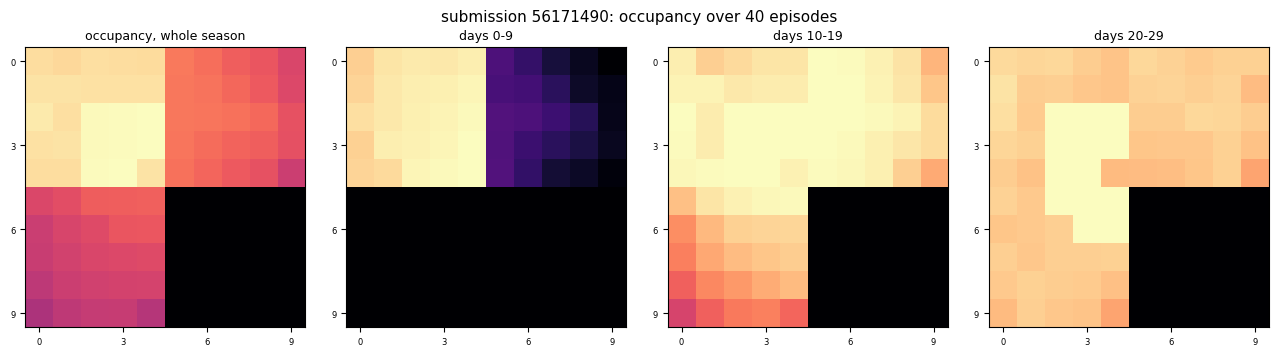

occupancy: chi2/dof 1,095.5 over 75 unlocked cells; the ten busiest hold 17.9% of the mass against 13.3% if the board were used evenly
occupancy: half-split correlation r = +1.000   (below about +0.9, read the map as one season's noise)


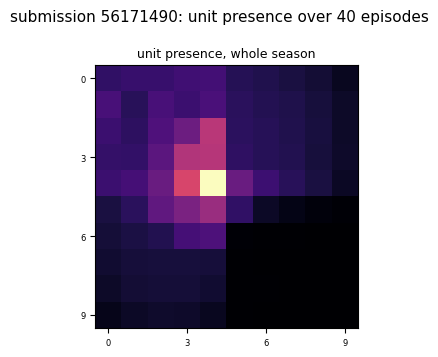

unit presence: chi2/dof 2,264.1 over 75 unlocked cells; the ten busiest hold 33.6% of the mass against 13.3% if the board were used evenly
unit presence: half-split correlation r = +0.999   (below about +0.9, read the map as one season's noise)


In [32]:
def _bh_corr(a, b):
    xa = [v for row in a for v in row]; xb = [v for row in b for v in row]
    ma = sum(xa) / len(xa); mb = sum(xb) / len(xb)
    num = sum((p - ma) * (q - mb) for p, q in zip(xa, xb))
    den = (sum((p - ma) ** 2 for p in xa) * sum((q - mb) ** 2 for q in xb)) ** 0.5
    return None if den == 0 else num / den

def _bh_uniformity(_bh_grid, unlocked):
    vals = [_bh_grid[y][x] for y in range(10) for x in range(10) if unlocked[y][x] > 0]
    tot = sum(vals)
    if not vals or tot == 0:
        return None
    exp = tot / len(vals)
    chi = sum((v - exp) ** 2 / exp for v in vals)
    top = sum(sorted(vals, reverse=True)[:10])
    return len(vals), chi / max(1, len(vals) - 1), top / tot, min(10, len(vals)) / len(vals)

def _bh_panel(ax, _bh_grid, title, vmax=None):
    ax.imshow(_bh_grid, cmap="magma", interpolation="nearest", vmin=0,
              vmax=vmax or max((v for r in _bh_grid for v in r), default=1) or 1)
    ax.set_title(title, fontsize=9)
    ax.set_xticks(range(0, 10, 3)); ax.set_yticks(range(0, 10, 3))
    ax.tick_params(labelsize=6)

_bh_days = sorted(OCC_DAY)
_bh_thirds = [Z(), Z(), Z()]
for d in _bh_days:
    i = min(2, d * 3 // max(1, len(_bh_days)))
    for y in range(10):
        for x in range(10):
            _bh_thirds[i][y][x] += OCC_DAY[d][y][x]

for _bh_name, _bh_grid, _bh_halves in (("occupancy", OCC, OCC_HALF), ("unit presence", PRES, PRES_HALF)):
    u = _bh_uniformity(_bh_grid, UNLOCKED)
    r = _bh_corr(_bh_halves[0], _bh_halves[1])
    # occupancy gets the three ten-day panels beside the season; presence does
    # not, because a unit's position is where it stands rather than what stands
    # there, and repeating one map four times says nothing four times.
    thirds_too = _bh_name == "occupancy"
    fig, axes = plt.subplots(1, 4 if thirds_too else 1,
                             figsize=(13, 3.4) if thirds_too else (3.6, 3.6))
    axes = list(axes) if thirds_too else [axes]
    _bh_panel(axes[0], _bh_grid, f"{_bh_name}, whole season")
    if thirds_too:
        for i in range(3):
            _bh_panel(axes[i + 1], _bh_thirds[i], f"days {i*10}-{i*10+9}")
    fig.suptitle(f"submission {SUBMISSION_ID}: {_bh_name} over {len(rows)} episodes", fontsize=11)
    plt.tight_layout(); plt.show()
    if u:
        _bh_ncells, _bh_chidof, _bh_topshare, _bh_flatshare = u
        print(f"{_bh_name}: chi2/dof {_bh_chidof:,.1f} over {_bh_ncells} unlocked cells; "
              f"the ten busiest hold {_bh_topshare:.1%} of the mass against "
              f"{_bh_flatshare:.1%} if the board were used evenly")
    print(f"{_bh_name}: half-split correlation "
          + ("not computable" if r is None else f"r = {r:+.3f}")
          + "   (below about +0.9, read the map as one season's noise)")

## 8. Productivity in time, against the leader's own band

Every unit-turn goes into exactly one of four buckets: **work** (plant, water, harvest, feed, care, fertilize, dig, build), **carry** (pickup, place, drop), **move** (the four compass steps) and **idle** (PASS). The buckets are exhaustive on purpose, and anything the engine emits that is not in them is printed rather than dropped, so a new verb announces itself instead of disappearing into a rounding error.

The comparison is against **today's number one, as a band rather than a line**. One agent's season is one sample, and a baseline drawn as a single line invites reading normal variation as a difference. The band is the 10th to 90th percentile of the leader's own episodes, per day. Every day your curve leaves it is circled.

**Read `move` before calling anything wasted.** Measured on 40 episodes of a leader against 40 of a mid-table agent, the leader spent **53.8 % of all its unit-turns walking and 3.8 % standing still**, against 42.9 % and 11.8 % for the other. The ten points of movement the weaker agent did not spend came back as idling in place. Movement is the cost of reaching a wide board; PASS is the thing with nothing on the other side of it.


king resolved by climbing the live ladder: 2,283 -> 2,282 -> 2,399 -> 2,730 -> 2,763 -> 2,342 -> 1,747 -> 1,803 -> 1,540 -> 1,815 -> 1,953 -> 2,015 -> 2,089 -> 2,717 -> 2,765


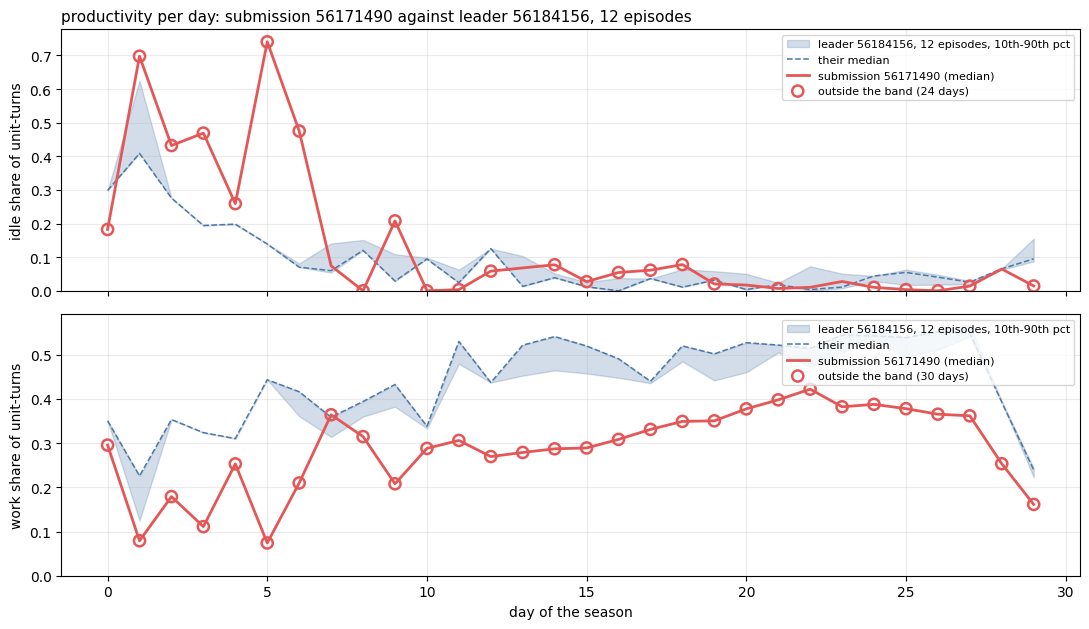

season-wide split of every unit-turn: work 28.7%  carry 1.9%  move 55.0%  idle 14.4%


In [33]:
_PR_WORK  = {"PLANT","HARVEST","FEED","CARE","COLLECT_FERTILIZER","FERTILIZE",
         "BUILD_PASTURE","BUILD_COOP","WATER","DIG"}
_PR_CARRY = {"PICKUP","PLACE","DROP"}
_PR_MOVE  = {"NORTH","SOUTH","EAST","WEST"}
_PR_IDLE  = {"PASS","NONE"}

def _pr_verb(a):
    if not a: return "NONE"
    if isinstance(a, str): return a
    return str(a[0]) if isinstance(a, list) and a else "NONE"

def _pr_bucket(v):
    return ("work" if v in _PR_WORK else "carry" if v in _PR_CARRY else
            "move" if v in _PR_MOVE else "idle" if v in _PR_IDLE else "unclassified")

def _pr_day_series(stream):
    """One row per day: the share of that day's unit-turns in each bucket."""
    days = {}
    for t, act in enumerate(stream):
        if not isinstance(act, dict): continue
        d = days.setdefault(t // 24, collections.Counter())
        d[_pr_bucket(_pr_verb(act.get("farmer")))] += 1
        for h in (act.get("hands") or []):
            d[_pr_bucket(_pr_verb(h))] += 1
    _pr_out = []
    for day in sorted(days):
        b = days[day]; n = sum(b.values())
        _pr_out.append({"day": day, **{k: (b[k] / n if n else 0.0)
                                   for k in ("work","carry","move","idle","unclassified")}})
    return _pr_out

def _pr_band_of(list_of_series):
    per = {}
    for s in list_of_series:
        for r in s:
            per.setdefault(r["day"], []).append(r)
    _pr_out = {}
    for day, rs in per.items():
        _pr_out[day] = {}
        for k in ("work","idle"):
            v = sorted(x[k] for x in rs)
            _pr_out[day][k] = (v[max(0, int(0.10*len(v)) - 1)],
                           v[len(v)//2],
                           v[min(len(v)-1, int(0.90*len(v)))])
    return _pr_out

_pr_ours = [_pr_day_series(r["stream"]) for r in rows]
_pr_unc = sum(x["unclassified"] for s in _pr_ours for x in s)
if _pr_unc:
    print(f"NOTE: {_pr_unc:.2f} day-shares fell in no bucket; a verb this cell does not know")

# the leader's _pr_band. When you ARE the leader, the _pr_band is your own episodes.
_pr_king = _resolve_king() if SUBMISSION_ID != "KING" else SUBMISSION_ID
if str(_pr_king) == str(SUBMISSION_ID):
    _pr_base, _pr_lab = _pr_ours, "your own episodes"
else:
    _pr_keps = requests.post(LIST_URL, json={"submissionId": _pr_king},
                         timeout=30).json().get("episodes", [])
    _pr_keps = [e for e in _pr_keps if e.get("state") == "COMPLETED"][:BASELINE_EPISODES]
    _pr_base = []
    for e in _pr_keps:
        rr = requests.get(REPLAY_URL.format(id=e["id"]), timeout=120)
        if not rr.ok: continue
        b = rr.json(); steps = b.get("steps") or []
        if len(steps) < 700: continue
        seats = {(a.get("index") or 0): a for a in e["agents"]}
        _pr_ks = next((i for i, a in seats.items()
                   if str(a.get("submissionId")) == str(_pr_king)), 0)
        _pr_base.append(_pr_day_series(
            [(steps[t+1][_pr_ks]["action"] if t+1 < len(steps) else None) or PASS
             for t in range(719)]))
    _pr_lab = f"leader {_pr_king}, {len(_pr_base)} episodes"

_pr_band = _pr_band_of(_pr_base)
_pr_med = [{"day": d, **{k: sorted(x[k] for x in [s[d] for s in _pr_ours if d < len(s)])
                     [len([s for s in _pr_ours if d < len(s)])//2]
                     for k in ("work","idle")}}
       for d in sorted({r["day"] for s in _pr_ours for r in s})
       if any(d < len(s) for s in _pr_ours)]

fig, axes = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True)
for ax, _pr_key in zip(axes, ("idle", "work")):
    _pr_xs = [r["day"] for r in _pr_med]
    _pr_lo = [_pr_band.get(d, {}).get(_pr_key, (0,0,0))[0] for d in _pr_xs]
    _pr_mid = [_pr_band.get(d, {}).get(_pr_key, (0,0,0))[1] for d in _pr_xs]
    _pr_hi = [_pr_band.get(d, {}).get(_pr_key, (0,0,0))[2] for d in _pr_xs]
    ax.fill_between(_pr_xs, _pr_lo, _pr_hi, alpha=0.25, color="#4c78a8", label=f"{_pr_lab}, 10th-90th pct")
    ax.plot(_pr_xs, _pr_mid, color="#4c78a8", lw=1.1, ls="--", label="their median")
    _pr_ys = [r[_pr_key] for r in _pr_med]
    ax.plot(_pr_xs, _pr_ys, color="#e45756", lw=2.0, label=f"submission {SUBMISSION_ID} (median)")
    _pr_out = [(d, y) for d, y, a, b_ in zip(_pr_xs, _pr_ys, _pr_lo, _pr_hi) if y > b_ or y < a]
    if _pr_out:
        ax.scatter([d for d, _ in _pr_out], [y for _, y in _pr_out], s=64, zorder=5,
                   facecolors="none", edgecolors="#e45756", linewidths=1.8,
                   label=f"outside the band ({len(_pr_out)} days)")
    ax.set_ylabel(f"{_pr_key} share of unit-turns"); ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc="upper right"); ax.set_ylim(bottom=0)
axes[-1].set_xlabel("day of the season")
axes[0].set_title(f"productivity per day: submission {SUBMISSION_ID} against {_pr_lab}",
                  fontsize=11, loc="left")
plt.tight_layout(); plt.show()

_pr_tot = collections.Counter()
for _pr_s in _pr_ours:
    for _pr_r in _pr_s:
        for _pr_k in ("work","carry","move","idle"):
            _pr_tot[_pr_k] += _pr_r[_pr_k]
_pr_n = sum(_pr_tot.values()) or 1
print("season-wide split of every unit-turn: "
      + "  ".join(f"{_pr_k} {_pr_tot[_pr_k]/_pr_n:.1%}"
                     for _pr_k in ("work","carry","move","idle")))

### Staffing in time, against the rivals you actually met

The field agrees on hiring more than on anything else it does. Measured over **490 seat-seasons** (both seats of 245 full replays, many distinct teams), the interquartile spread of hands-on-the-board is **0-2 hands on every day of the season**: four hands to day 4, a ramp through 8 to eleven by day 10, and **twelve from day 13 to the bell**. A consensus that tight is a heuristic bound: a staffing curve outside it is a claim that needs evidence, not a style.

The band here is built from the **rivals these very episodes were played against**, so it is the consensus of the field you actually met. Days where your median leaves the band are circled.


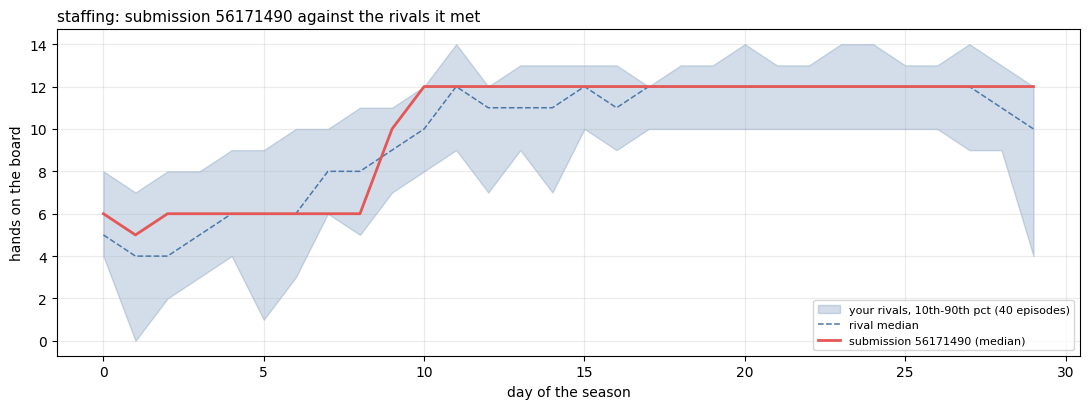

field-wide reference (490 seasons): 4 hands to day 4, 8 by day 6, 11 by day 10, 12 from day 13 to the bell; IQR 0-2 hands all season


In [34]:
_hr_days = list(range(30))
_hr_ours = [sorted(r["hands_me"][d] for r in rows)[len(rows)//2] for d in _hr_days]
_hr_rows_op = [r["hands_op"] for r in rows]
def _hr_q(d, p):
    v = sorted(x[d] for x in _hr_rows_op)
    return v[min(len(v)-1, int(p*len(v)))]
_hr_lo  = [_hr_q(d, .10) for d in _hr_days]
_hr_md  = [_hr_q(d, .50) for d in _hr_days]
_hr_hi  = [_hr_q(d, .90) for d in _hr_days]

_hr_fig, _hr_ax = plt.subplots(figsize=(11, 4.2))
_hr_ax.fill_between(_hr_days, _hr_lo, _hr_hi, alpha=0.25, color="#4c78a8",
                    label=f"your rivals, 10th-90th pct ({len(rows)} episodes)")
_hr_ax.plot(_hr_days, _hr_md, color="#4c78a8", lw=1.1, ls="--", label="rival median")
_hr_ax.plot(_hr_days, _hr_ours, color="#e45756", lw=2.0,
            label=f"submission {SUBMISSION_ID} (median)")
_hr_out = [(d, y) for d, y, a, b in zip(_hr_days, _hr_ours, _hr_lo, _hr_hi)
           if y < a or y > b]
if _hr_out:
    _hr_ax.scatter([d for d, _ in _hr_out], [y for _, y in _hr_out], s=64,
                   zorder=5, facecolors="none", edgecolors="#e45756",
                   linewidths=1.8, label=f"outside the band ({len(_hr_out)} days)")
_hr_ax.set_xlabel("day of the season"); _hr_ax.set_ylabel("hands on the board")
_hr_ax.grid(alpha=0.25); _hr_ax.legend(fontsize=8, loc="lower right")
_hr_ax.set_title(f"staffing: submission {SUBMISSION_ID} against the rivals it met",
                 fontsize=11, loc="left")
plt.tight_layout(); plt.show()
print("field-wide reference (490 seasons): 4 hands to day 4, 8 by day 6, "
      "11 by day 10, 12 from day 13 to the bell; IQR 0-2 hands all season")
if _hr_out:
    print(f"days outside your rivals' band: {[d for d, _ in _hr_out]}")

## 9. Convergence

Before quoting the rating this submission holds, ask whether the number has stopped moving, and measure that in the only unit that works here: **the EPISODE, never the minute**. The leaderboard updates in batches, so dividing by wall-clock time counts minutes in which nothing happened; I have watched a per-hour average say a rating was crawling while per-episode sampling showed it climbing six points a game.

Three numbers together, never one:

* **DRIFT**, the mean rating change per new episode over the recent window.
* **SIGN FLIPS**, how often consecutive per-episode deltas change direction.
* **n**, the episodes played. Warming up is drift above the threshold with no flips, the number still travelling one way and misstating the agent. Settled is drift at or below the threshold with at least one flip. The threshold is a decision, not a constant: one point per episode here, stated with the verdict, and **a verdict quoted without its threshold is not a verdict**.

The pairing rate is its own diagnostic, and it is **not part of the verdict on purpose**. The matchmaker sets how often you play by its own placement uncertainty, so a fresh or badly placed submission gets paired hard and a settled one cools down: the rate chart usually starts hot and decays, and a falling rate is itself evidence the system thinks it knows where you belong. The drift is measured per EPISODE precisely so the verdict does not depend on that schedule; weighting convergence by frequency would re-import the wall-clock error this section exists to avoid. What frequency is for is the calendar: episodes-to-settle divided by the current rate is how long to wait before reading the number again, and I print that conversion below.

The rating curve is colored by its own speed, the rolling per-episode |drift|: **warm stretches are above the threshold and still travelling, cool stretches are below it and settling**, so each moment of the curve declares its regime at a glance.

SETTLED  (drift -0.18 pts/episode over the last 20, 9 sign flips, threshold 1.0, n=45 episodes, rating now 706.7)


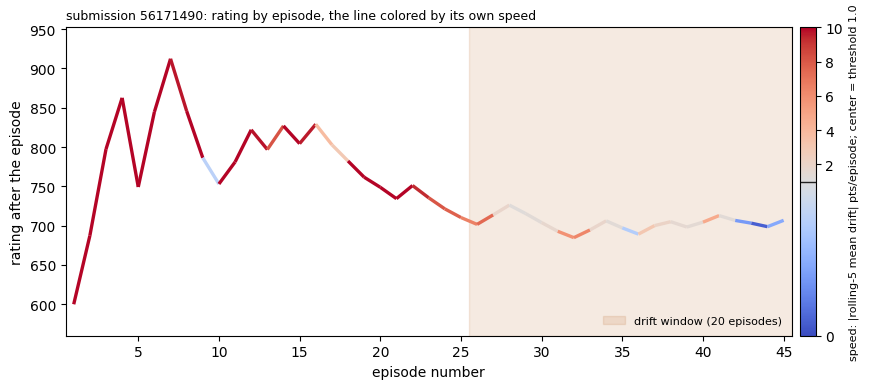

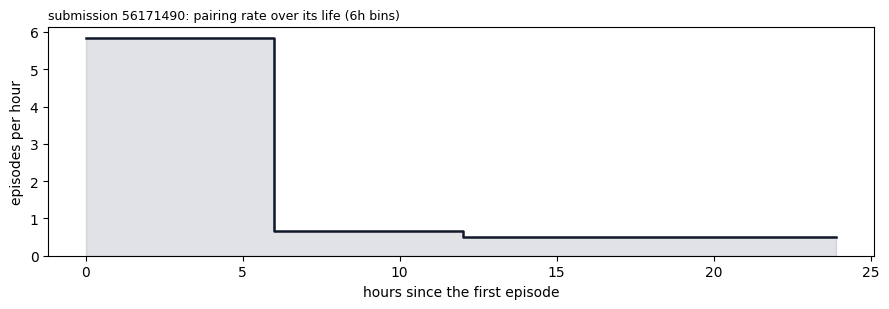

pairing rate: 1.9 episodes/hour lifetime, 1.9/hour in the last 24h
at the current rate the 20-episode drift window refreshes in about 11 hours: that is when to read again


In [35]:
THRESH = 1.0   # points per episode; state it with the verdict
WIN = min(20, len(traj) - 1)
if len(traj) < 4:
    print(f"only {len(traj)} rated episodes: too few to classify, the rating is a rumour")
else:
    deltas = [b - a for a, b in zip(traj[-WIN - 1:-1], traj[-WIN:])]
    drift = sum(deltas) / len(deltas)
    nz = [d for d in deltas if d != 0]
    flips = sum(1 for a, b in zip(nz, nz[1:]) if (a > 0) != (b > 0))
    if abs(drift) > THRESH and flips == 0:
        conv_verdict = "WARMING UP"
    elif abs(drift) > THRESH:
        conv_verdict = "SETTLING"
    else:
        conv_verdict = "SETTLED" if flips >= 1 else "SETTLING"
    print(f"{conv_verdict}  (drift {drift:+.2f} pts/episode over the last {WIN}, "
          f"{flips} sign flips, threshold {THRESH}, n={len(traj)} episodes, "
          f"rating now {traj[-1]:,.1f})")
    from matplotlib.collections import LineCollection
    from matplotlib.colors import TwoSlopeNorm
    dsign = [b - a for a, b in zip(traj, traj[1:])]
    Wm = 5
    roll = [abs(sum(dsign[max(0, i - Wm + 1):i + 1]) / (i - max(0, i - Wm + 1) + 1))
            for i in range(len(dsign))]
    pts = np.array([[i + 1, v] for i, v in enumerate(traj)], dtype=float)
    segs = np.stack([pts[:-1], pts[1:]], axis=1)
    vmax_s = max(10.0, 2 * THRESH)
    fig3, ax3 = plt.subplots(figsize=(9.5, 4))
    lc = LineCollection(segs, cmap="coolwarm",
                        norm=TwoSlopeNorm(vmin=0.0, vcenter=THRESH, vmax=vmax_s))
    lc.set_array(np.clip(np.array(roll), 0, vmax_s))
    lc.set_linewidth(2.4)
    ax3.add_collection(lc)
    ax3.set_xlim(0.5, len(traj) + 0.5)
    ax3.set_ylim(min(traj) - 40, max(traj) + 40)
    ax3.axvspan(len(traj) - WIN + 0.5, len(traj) + 0.5, color=MUT, alpha=0.12,
                label=f"drift window ({WIN} episodes)")
    cb = fig3.colorbar(lc, ax=ax3, pad=0.01)
    cb.set_label(f"speed: |rolling-{Wm} mean drift| pts/episode; center = threshold {THRESH}",
                 fontsize=8)
    cb.ax.axhline(THRESH, color="#222", lw=1.0)
    ax3.set_xlabel("episode number"); ax3.set_ylabel("rating after the episode")
    ax3.set_title(f"submission {SUBMISSION_ID}: rating by episode, "
                  "the line colored by its own speed", fontsize=9, loc="left")
    ax3.legend(frameon=False, fontsize=8, loc="lower right")
    plt.tight_layout(); plt.show()

import datetime as _dt
ts = sorted(_dt.datetime.strptime(e["endTime"][:19], "%Y-%m-%dT%H:%M:%S")
            for e in eps if e.get("endTime"))
if len(ts) >= 3:
    import math
    t0, t1 = ts[0], ts[-1]
    span_h = max(1.0, (t1 - t0).total_seconds() / 3600)
    nbin = max(1, math.ceil(span_h / 6))
    counts = [0] * nbin
    for t in ts:
        counts[min(nbin - 1, int((t - t0).total_seconds() // (6 * 3600)))] += 1
    widths = [min(6.0, span_h - 6 * k) for k in range(nbin)]
    xs_r, ys_r = [], []
    for k in range(nbin):
        w = max(widths[k], 0.5)
        r = counts[k] / w
        xs_r += [6 * k, 6 * k + w]
        ys_r += [r, r]
    figR, axR = plt.subplots(figsize=(9, 3.2))
    axR.plot(xs_r, ys_r, color=PLAN, lw=1.8)
    axR.fill_between(xs_r, ys_r, 0, color=PLAN, alpha=0.12)
    axR.set_ylim(bottom=0)
    axR.set_xlabel("hours since the first episode")
    axR.set_ylabel("episodes per hour")
    axR.set_title(f"submission {SUBMISSION_ID}: pairing rate over its life (6h bins)",
                  fontsize=9, loc="left")
    plt.tight_layout(); plt.show()
    last24 = sum(1 for t in ts if (t1 - t).total_seconds() <= 24 * 3600) / min(24.0, span_h)
    print(f"pairing rate: {len(ts) / span_h:.1f} episodes/hour lifetime, "
          f"{last24:.1f}/hour in the last 24h")
    if len(traj) >= 4 and last24 > 0:
        print(f"at the current rate the {WIN}-episode drift window refreshes "
              f"in about {WIN / last24:.0f} hours: that is when to read again")

## 10. The report

Everything above in one block, the exact format my local instrument writes to **report.txt**: ledger, texture, classification, worlds, kinship, macro profile and convergence, ready to paste or diff.

In [36]:
lab = f"submission {SUBMISSION_ID}"
print(f"{lab}: {len(rows)} episodes, {len({r['pair'] for r in rows})} distinct worlds")
mg2 = sorted(r["margin"] for r in rows)
W2 = sum(1 for r in rows if r["margin"] > 0)
L2 = sum(1 for r in rows if r["margin"] < 0)
print(f"  ledger  W{W2}-L{L2}-T{len(rows) - W2 - L2}, margin median {mg2[len(mg2) // 2]:+,.0f}, "
      f"worst {mg2[0]:+,.0f}, best {mg2[-1]:+,.0f}")
print(f"  texture green {share[0] / tot:.1%}  amber {share[1] / tot:.1%}  navy {share[2] / tot:.1%}")
print(f"\n  GLOBAL class: {gcls}  (varying {g['frac']:.1%}, "
      f"first divergence t={g['first']}, channels {g['chan']})")
if gcls == "ADAPTIVE" and g["first"] is not None and 70 <= g["first"] <= 146:
    print("    NOTE a plan fork at t in [72, 144] with the shop draw is "
          "ROUTING, not reactivity; read the within-world table.")
print(f"\n  {'world':<34} {'n':>3} {'class':<17} {'vary':>6} {'first_div':>9}")
for t in tbl:
    if t["n"] < 2:
        print(f"  {t['world']:<34} {t['n']:>3} {'(one episode)':<17}")
    else:
        print(f"  {t['world']:<34} {t['n']:>3} {t['cls']:<17} {t['vary']:>6} {str(t['first']):>9}")
print(f"\n  within-world verdict: {dict(verdict)}")
km = [k for k in kin if k["plan"] >= 0.95]
print(f"  kinship: {len(km)} mirrors, {len([k for k in kin if 0.5 <= k['plan'] < 0.95])} siblings, "
      f"{len(kin)} opponents read")
print("\n  macro profile, median [p10, p90]; ref = the measured #1 shape")
mrow("2nd quadrant, day", [m["land2"] for m in M], "5")
mrow("care actions", [m["care"] for m in M], "280")
print(f"  {'herd bought (median)':<30} COW {herd_med['COW']}  SHEEP {herd_med['SHEEP']}  "
      f"GOOSE {herd_med['GOOSE']}    ref 7 COW")
mrow("endgame fallow tiles d25-29", [m["fallow_late"] for m in M], "13")
mrow("stranded $ at the bell", [m["stranded"] for m in M], "442")
if len(traj) >= 4:
    print(f"\n  convergence: {conv_verdict}  (drift {drift:+.2f} pts/episode, "
          f"{flips} flips, threshold {THRESH}, n={len(traj)}, rating {traj[-1]:,.1f})")

submission 56171490: 40 episodes, 29 distinct worlds
  ledger  W16-L24-T0, margin median -2,695, worst -45,899, best +46,451
  texture green 28.0%  amber 2.4%  navy 69.5%

  GLOBAL class: ADAPTIVE  (varying 80.9%, first divergence t=25, channels {'farmer': 526, 'hands': 551, 'market': 505})

  world                                n class               vary first_div
  BAKERY__BAKERY                       1 (one episode)    
  BAKERY__FARMERS_MARKET               1 (one episode)    
  BAKERY__ICE_CREAM_SHOP               1 (one episode)    
  BAKERY__YARN_STORE                   1 (one episode)    
  BRUNCH_SPOT__FARMERS_MARKET          2 ADAPTIVE           74.7%       168
  BRUNCH_SPOT__ICE_CREAM_SHOP          1 (one episode)    
  BRUNCH_SPOT__PIZZA_SHOP              1 (one episode)    
  BRUNCH_SPOT__SMOOTHIE_SHOP           2 ADAPTIVE           74.8%        68
  BRUNCH_SPOT__YARN_STORE              1 (one episode)    
  FARMERS_MARKET__ICE_CREAM_SHOP       1 (one episode)    
  FARME

## 11. Caveats and credits

* **The mode is computed from the episodes shown**, so with very few episodes the mode itself is weak.
* **Nothing observable differs before turn 48** in this game, so early agreement between ANY two agents is the engine's determinism, not evidence of anything.
* **The turn convention**: the action decided at turn t is stored at steps[t + 1] of the replay, and the day is turn // 24. Use the raw index and the whole picture shifts by one turn.

If this found something odd in your agent, the follow-ups are in [a DNA test for agents](https://www.kaggle.com/code/destbreso/a-dna-test-for-agents). And the replay route I fetch from is the one [georgymamarin's dataset](https://www.kaggle.com/datasets/georgymamarin/kaggriculture-episodes) crawls nightly: vote for it, his scraper is where I learned the endpoint.